In [1]:
import os
import pandas as pd

TRAIN_DIR = "data/train"
CSV_PATH = "train.csv"

df = pd.read_csv(CSV_PATH)

label_to_folder = {
    0: "dark",
    1: "normal",
    2: "bright"
}

df["image_path"] = df.apply(
    lambda row: os.path.join(
        TRAIN_DIR,
        label_to_folder[row["label"]],
        row["id"] + ".png"      # <-- THIS IS THE FIX
    ),
    axis=1
)

print(df.head())
print(f"Total Images : {len(df)}")

                                     id  label  \
0  02137a86-0743-40e0-845b-6d22d1d5cc85      0   
1  025d39a8-7859-4558-9bf9-bbdd475c6100      0   
2  02a2a878-c5a4-490a-8061-6b2f4ac3b6d0      0   
3  047f7996-9f0d-4a04-ae7f-24e246c407c7      0   
4  052a9d62-a31f-4e4f-9a76-edac2d2ae95d      0   

                                          image_path  
0  data/train/dark/02137a86-0743-40e0-845b-6d22d1...  
1  data/train/dark/025d39a8-7859-4558-9bf9-bbdd47...  
2  data/train/dark/02a2a878-c5a4-490a-8061-6b2f4a...  
3  data/train/dark/047f7996-9f0d-4a04-ae7f-24e246...  
4  data/train/dark/052a9d62-a31f-4e4f-9a76-edac2d...  
Total Images : 1500


In [2]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights

from PIL import Image

from tqdm import tqdm

### Load Your Trained Model

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained ResNet18
weights = ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

# Replace classifier exactly like training
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_features, 3)
)

# Load your trained weights
MODEL_PATH = "best_model.pth"      # <-- CHANGE THIS

model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

print("Model Loaded Successfully")

Model Loaded Successfully


#### Convert ResNet into a Feature Extractor

In [4]:
feature_extractor = nn.Sequential(
    *list(model.children())[:-1]
)

feature_extractor.to(DEVICE)
feature_extractor.eval()

print(feature_extractor)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (

### Image Transform

In [5]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

### Feature Extraction Function

In [6]:
def extract_resnet_feature(path):

    image = Image.open(path).convert("RGB")

    image = transform(image)

    image = image.unsqueeze(0).to(DEVICE)

    with torch.no_grad():

        feature = feature_extractor(image)

    feature = feature.squeeze()

    feature = feature.cpu().numpy()

    return feature

### Extract Features for Every Image

In [7]:


feature_vectors = []

labels = []

image_names = []

for _, row in tqdm(df.iterrows(), total=len(df)):

    feature = extract_resnet_feature(row.image_path)

    feature_vectors.append(feature)

    labels.append(row.label)

    image_names.append(row.id)

100%|██████████| 1500/1500 [00:38<00:00, 38.58it/s]


### Create DataFrame

In [8]:
import numpy as np
feature_vectors = np.array(feature_vectors)

print(feature_vectors.shape)

(1500, 512)


In [9]:
print(df.head())
import os

files = os.listdir("data/train/dark")

print(files[:5])

                                     id  label  \
0  02137a86-0743-40e0-845b-6d22d1d5cc85      0   
1  025d39a8-7859-4558-9bf9-bbdd475c6100      0   
2  02a2a878-c5a4-490a-8061-6b2f4ac3b6d0      0   
3  047f7996-9f0d-4a04-ae7f-24e246c407c7      0   
4  052a9d62-a31f-4e4f-9a76-edac2d2ae95d      0   

                                          image_path  
0  data/train/dark/02137a86-0743-40e0-845b-6d22d1...  
1  data/train/dark/025d39a8-7859-4558-9bf9-bbdd47...  
2  data/train/dark/02a2a878-c5a4-490a-8061-6b2f4a...  
3  data/train/dark/047f7996-9f0d-4a04-ae7f-24e246...  
4  data/train/dark/052a9d62-a31f-4e4f-9a76-edac2d...  
['02a2a878-c5a4-490a-8061-6b2f4ac3b6d0.png', 'a4fa6c2f-267c-426f-bfa1-9113ab19e805.png', 'e8dd6a61-2a4f-4729-b0e6-425bc9d90ae2.png', '775fc0dc-e905-4672-b34d-73cf70bc0609.png', '5c89be72-cd1b-40fa-83fa-477807219f3a.png']


In [10]:
print(df.iloc[0]["image_path"])

data/train/dark/02137a86-0743-40e0-845b-6d22d1d5cc85.png


In [11]:
import os

print(os.path.exists(df.iloc[0]["image_path"]))

True


### Extract ResNet Features

In [12]:
master_data = []

for _, row in tqdm(df.iterrows(), total=len(df)):

    # Deep Feature
    feature = extract_resnet_feature(row.image_path)

    sample = {
        "image": row.id,
        "label": row.label
    }

    # Add ResNet Features
    for i in range(512):
        sample[f"resnet_{i}"] = feature[i]

    master_data.append(sample)

master_df = pd.DataFrame(master_data)

master_df.head()

100%|██████████| 1500/1500 [00:35<00:00, 41.72it/s]


,image,label,resnet_0,resnet_1,resnet_2,resnet_3,resnet_4,resnet_5,resnet_6,resnet_7,...,resnet_502,resnet_503,resnet_504,resnet_505,resnet_506,resnet_507,resnet_508,resnet_509,resnet_510,resnet_511
0,02137a86-0743-40e0-845b-6d22d1d5cc85,0,1.503252,0.733779,1.513309,0.041626,1.466866,1.763368,0.650255,1.772707,...,1.685473,0.089838,0.565075,1.063030,0.742253,0.548735,0.977023,0.234568,1.384308,0.575205
1,025d39a8-7859-4558-9bf9-bbdd475c6100,0,1.567873,1.037666,0.364339,0.587060,1.974926,1.137942,0.527725,0.449724,...,0.279744,0.618367,0.540192,3.436490,2.076207,0.436047,0.290990,1.178626,0.741967,0.428287
2,02a2a878-c5a4-490a-8061-6b2f4ac3b6d0,0,0.411265,1.356105,1.317105,0.094091,0.854148,0.370707,0.005329,0.210806,...,0.877450,0.399507,0.964876,1.779683,0.078416,0.693545,0.508940,0.199606,0.018365,0.465379
3,047f7996-9f0d-4a04-ae7f-24e246c407c7,0,1.107608,3.403687,1.248990,0.789486,0.320989,2.138436,2.261848,1.083504,...,1.335343,0.806069,1.044957,1.080118,0.747630,0.015274,0.673897,0.666867,0.717901,0.218544
4,052a9d62-a31f-4e4f-9a76-edac2d2ae95d,0,1.085853,1.090163,1.399769,1.643254,0.359540,0.761260,0.610737,1.538106,...,0.982408,0.407484,0.560537,0.850064,0.370739,0.031080,0.542728,0.668791,0.933221,0.123311


In [13]:
# Save
master_df.to_csv("resnet_features.csv", index=False)

print("Saved Successfully")

Saved Successfully


### Create a DataFrame of ResNet Features

In [14]:
feature_df = pd.DataFrame(feature_vectors)

feature_df["label"] = labels
feature_df["image"] = image_names

print(feature_df.shape)
feature_df.head()

(1500, 514)


,0,1,2,3,4,5,6,7,8,9,...,504,505,506,507,508,509,510,511,label,image
0,1.503252,0.733779,1.513309,0.041626,1.466866,1.763368,0.650255,1.772707,0.299647,1.052937,...,0.565075,1.063030,0.742253,0.548735,0.977023,0.234568,1.384308,0.575205,0,02137a86-0743-40e0-845b-6d22d1d5cc85
1,1.567873,1.037666,0.364339,0.587060,1.974926,1.137942,0.527725,0.449724,1.367495,0.769878,...,0.540192,3.436490,2.076207,0.436047,0.290990,1.178626,0.741967,0.428287,0,025d39a8-7859-4558-9bf9-bbdd475c6100
2,0.411265,1.356105,1.317105,0.094091,0.854148,0.370707,0.005329,0.210806,1.913395,0.967725,...,0.964876,1.779683,0.078416,0.693545,0.508940,0.199606,0.018365,0.465379,0,02a2a878-c5a4-490a-8061-6b2f4ac3b6d0
3,1.107608,3.403687,1.248990,0.789486,0.320989,2.138436,2.261848,1.083504,1.164568,1.575659,...,1.044957,1.080118,0.747630,0.015274,0.673897,0.666867,0.717901,0.218544,0,047f7996-9f0d-4a04-ae7f-24e246c407c7
4,1.085853,1.090163,1.399769,1.643254,0.359540,0.761260,0.610737,1.538106,0.640254,2.396883,...,0.560537,0.850064,0.370739,0.031080,0.542728,0.668791,0.933221,0.123311,0,052a9d62-a31f-4e4f-9a76-edac2d2ae95d


### PCA (2D Visualization

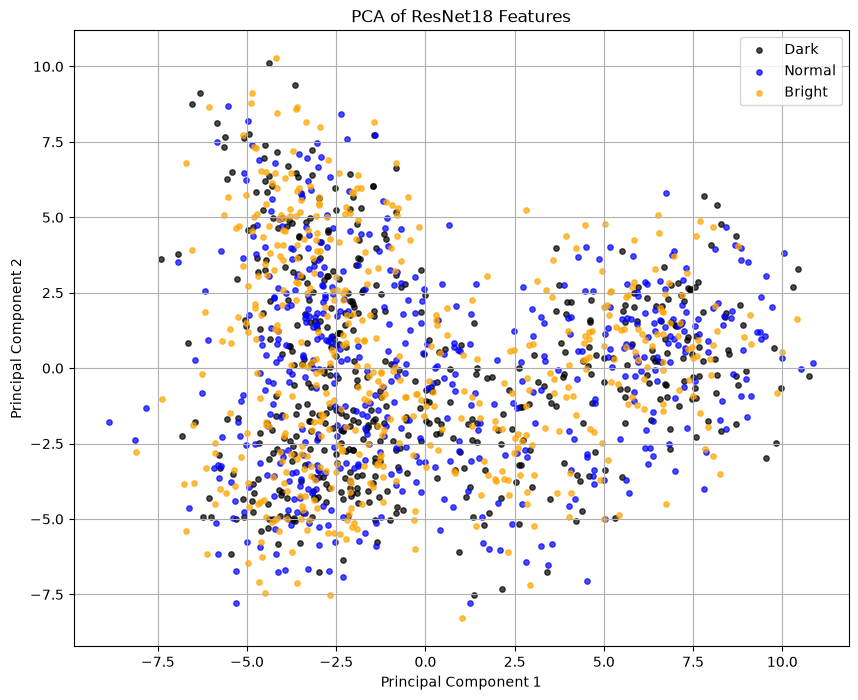

In [15]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X = feature_vectors

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10,8))

colors = {
    0: "black",
    1: "blue",
    2: "orange"
}

names = {
    0: "Dark",
    1: "Normal",
    2: "Bright"
}

for label in sorted(set(labels)):
    idx = [i for i, l in enumerate(labels) if l == label]
    plt.scatter(
        X_pca[idx,0],
        X_pca[idx,1],
        s=15,
        alpha=0.7,
        color=colors[label],
        label=names[label]
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of ResNet18 Features")
plt.legend()
plt.grid(True)
plt.show()

### t-SNE (Much Better Than PCA)

In [16]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca"
)

X_tsne = tsne.fit_transform(feature_vectors)

### Plot t-SNE

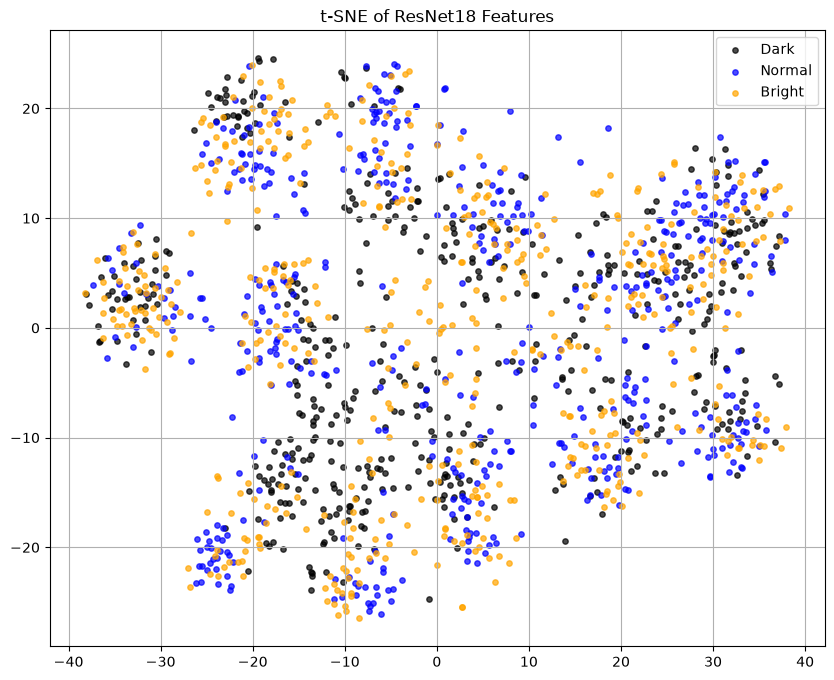

In [17]:
plt.figure(figsize=(10,8))

for label in sorted(set(labels)):
    idx = [i for i, l in enumerate(labels) if l == label]
    plt.scatter(
        X_tsne[idx,0],
        X_tsne[idx,1],
        s=15,
        alpha=0.7,
        color=colors[label],
        label=names[label]
    )

plt.title("t-SNE of ResNet18 Features")
plt.legend()
plt.grid(True)
plt.show()

### Feature Importance (ANOVA F-test)

In [18]:
from sklearn.feature_selection import f_classif
import pandas as pd

F, p = f_classif(feature_vectors, labels)

importance = pd.DataFrame({
    "Neuron": range(512),
    "F_score": F,
    "p_value": p
})

importance = importance.sort_values(
    by="F_score",
    ascending=False
)

importance.head(20)

,Neuron,F_score,p_value
273,273,121.764097,1.008654e-49
147,147,89.851232,1.406694e-37
153,153,87.380025,1.281803e-36
97,97,76.444283,2.447596e-32
293,293,68.198972,4.509745e-29
401,401,66.123677,3.028516e-28
235,235,64.624508,1.202301e-27
415,415,58.722468,2.806240e-25
495,495,57.965772,5.662260e-25
95,95,57.813691,6.520729e-25


### Plot Top 20 Neurons

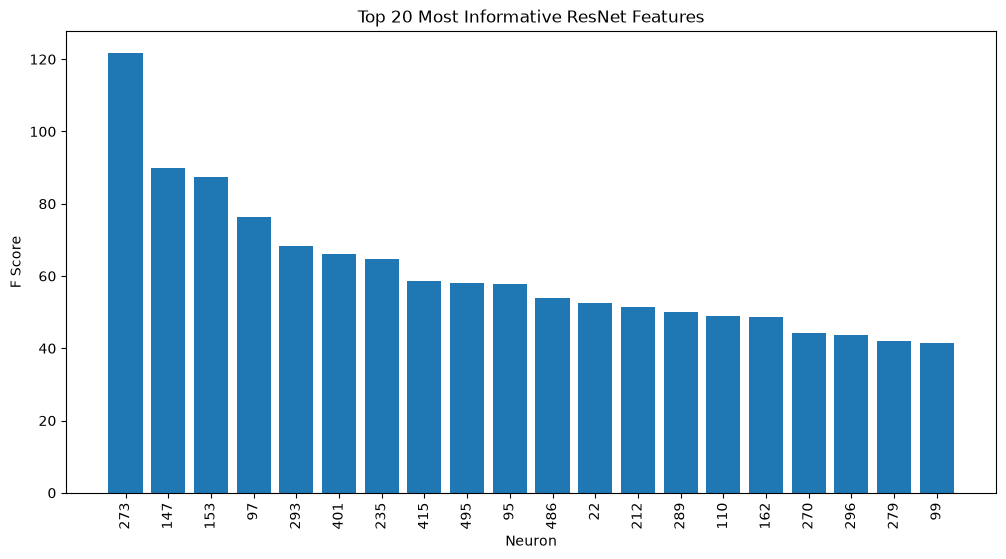

In [19]:
import matplotlib.pyplot as plt

top20 = importance.head(20)

plt.figure(figsize=(12,6))

plt.bar(
    top20["Neuron"].astype(str),
    top20["F_score"]
)

plt.xticks(rotation=90)

plt.title("Top 20 Most Informative ResNet Features")

plt.xlabel("Neuron")

plt.ylabel("F Score")

plt.show()

### Distribution of Best Neuron

In [20]:
best_feature = importance.iloc[0]["Neuron"]

best_feature = int(best_feature)

print("Best Feature:", best_feature)

Best Feature: 273


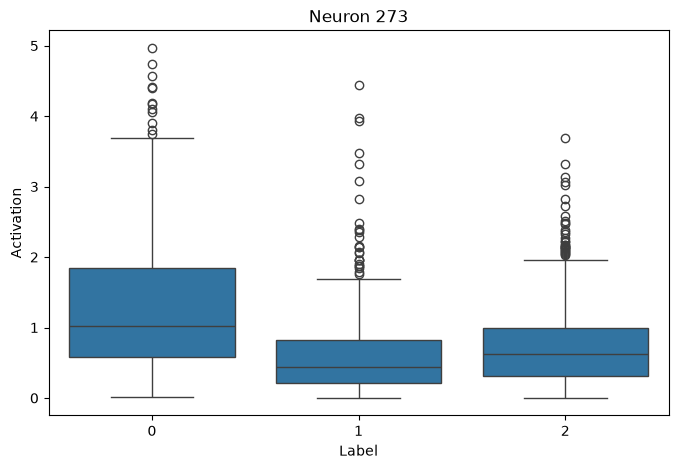

In [21]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    x=labels,
    y=feature_vectors[:, best_feature]
)

plt.xlabel("Label")
plt.ylabel("Activation")

plt.title(f"Neuron {best_feature}")

plt.show()

### Before adding another branch (YOLO), we should understand what the current model has actually learned

### Train on the Full Dataset

In [26]:
import pandas as pd

hybrid_df = pd.read_csv("hybrid_features.csv")

X = hybrid_df.drop(columns=["id", "label"])
y = hybrid_df["label"]

print(X.shape)
print(y.shape)

(1500, 535)
(1500,)


In [27]:
from xgboost import XGBClassifier

model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss",
    tree_method="hist",
    device="cuda"
)

model.fit(X, y)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegress

### Feature Importance DataFrame

In [29]:
print(type(X))

print(type(X))
print(type(model.feature_importances_))
print(len(model.feature_importances_))

print(X.shape)

<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>
<class 'numpy.ndarray'>
535
(1500, 535)


In [30]:
importance_df = pd.DataFrame({
    "Feature": X.columns.tolist(),
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
521,v_mean,0.014416
534,dark_ratio,0.012964
273,resnet_273,0.009103
513,median_gray,0.007186
153,resnet_153,0.006883
147,resnet_147,0.005849
210,resnet_210,0.004356
168,resnet_168,0.004211
86,resnet_86,0.004088
159,resnet_159,0.003998


### Top 30 Feature Importance Plot

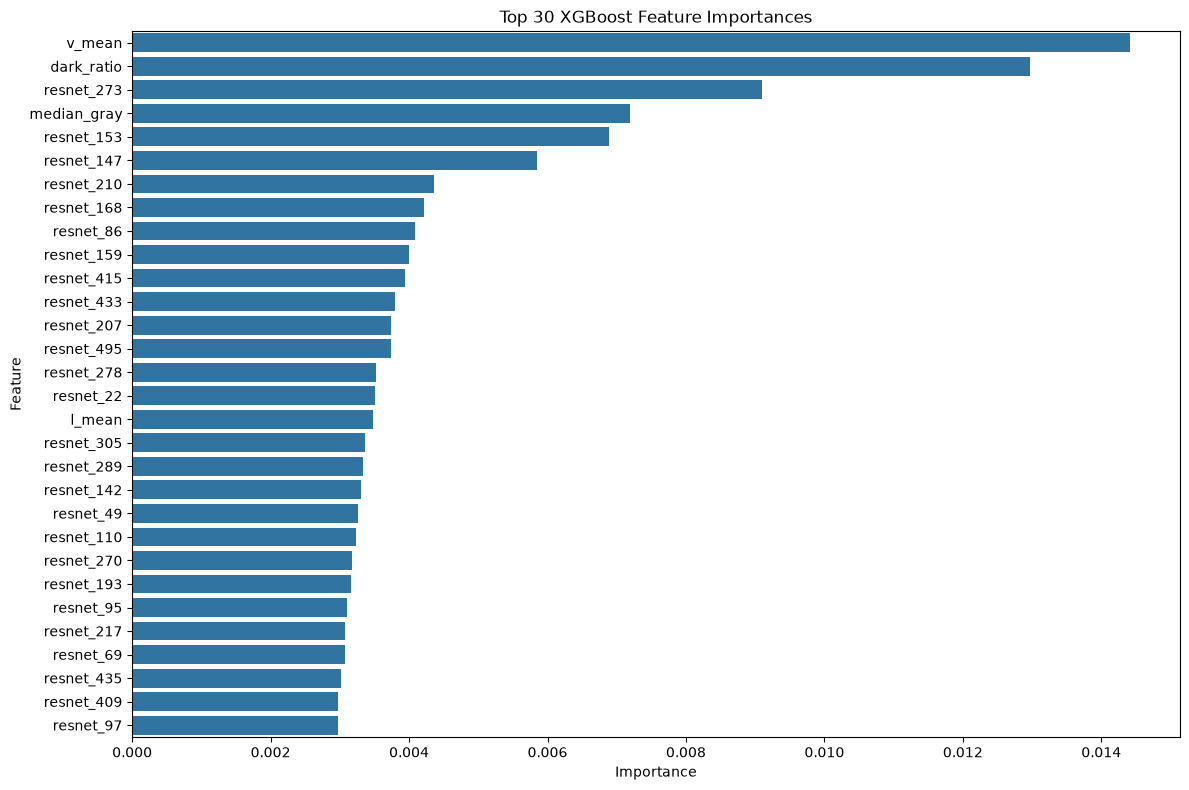

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.barplot(
    data=importance_df.head(30),
    x="Importance",
    y="Feature"
)

plt.title("Top 30 XGBoost Feature Importances")
plt.tight_layout()
plt.show()

### ResNet vs Handcrafted Contribution

In [32]:
resnet_importance = importance_df[
    importance_df["Feature"].str.startswith("resnet_")
]["Importance"].sum()

handcrafted_importance = importance_df[
    ~importance_df["Feature"].str.startswith("resnet_")
]["Importance"].sum()

print(f"ResNet Importance      : {resnet_importance:.4f}")
print(f"Handcrafted Importance : {handcrafted_importance:.4f}")

ResNet Importance      : 0.9279
Handcrafted Importance : 0.0721


### Handcrafted Features Only

In [33]:
handcrafted_importance = importance_df[
    ~importance_df["Feature"].str.startswith("resnet_")
]

handcrafted_importance

,Feature,Importance
521,v_mean,0.014416
534,dark_ratio,0.012964
513,median_gray,0.007186
525,l_mean,0.003473
531,edge_density,0.002404
516,max_gray,0.002328
518,entropy,0.002291
515,min_gray,0.002289
512,mean_gray,0.002277
530,b_std,0.002126


### Plot Only Handcrafted Features

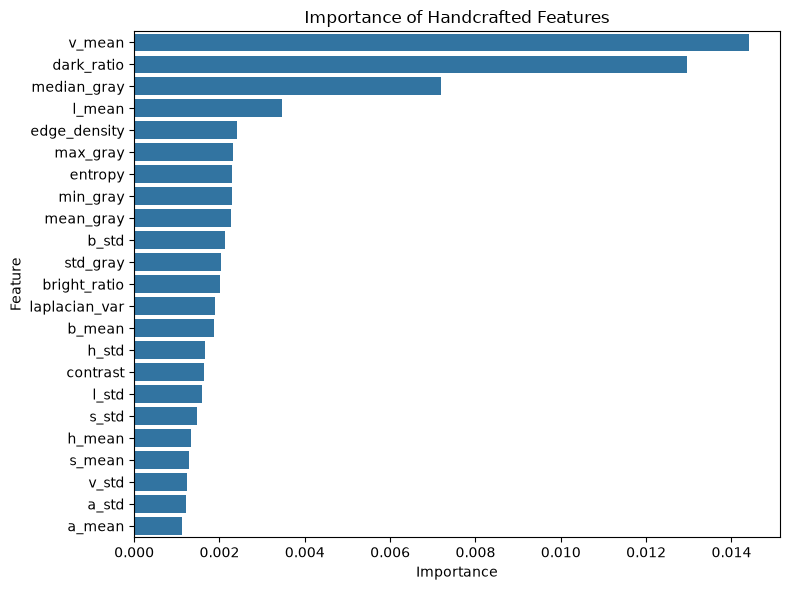

In [34]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=handcrafted_importance.sort_values(
        by="Importance",
        ascending=False
    ),
    x="Importance",
    y="Feature"
)

plt.title("Importance of Handcrafted Features")
plt.tight_layout()
plt.show()